In [27]:
# general imports
import matplotlib.pyplot as plt
%matplotlib inline
from braket.tracking import Tracker
from braket.circuits import Circuit
from braket.devices import LocalSimulator
import numpy as np
from braket.aws import AwsDevice
from braket.circuits import Circuit
from braket.circuits.observables import Z
from braket.devices import Devices, LocalSimulator
from qiskit_braket_provider import BraketLocalBackend
from qiskit_braket_provider import BraketProvider

t = Tracker().start()

In [8]:
bell = Circuit().h(0).cnot(control=0, target=1)

In [9]:
# set up device
device = LocalSimulator()

# run circuit
result = device.run(bell, shots=1000).result()
# get measurement shots
counts = result.measurement_counts
# print counts
print(counts)



Counter({'00': 507, '11': 493})


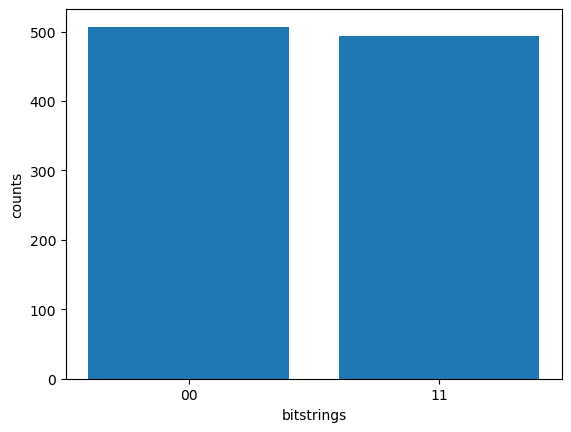

In [10]:
# plot using Counter
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstrings")
plt.ylabel("counts");

In [11]:
def ghz_circuit(n_qubits):
    # instantiate circuit object
    circuit = Circuit()

    # add Hadamard gate on first qubit
    circuit.h(0)

    # apply series of CNOT gates
    for ii in range(n_qubits - 1):
        circuit.cnot(control=ii, target=ii + 1)

    return circuit

In [14]:
# define circuit
n_qubits = 15
ghz = ghz_circuit(n_qubits)
# print circuit
print(ghz)

T   : │  0  │  1  │  2  │  3  │  4  │  5  │  6  │  7  │  8  │  9  │ 10  │  ╏
       ┌───┐                                                               ╏
q0  : ─┤ H ├───●─────────────────────────────────────────────────────────  ╏
       └───┘   │                                                           ╏
             ┌─┴─┐                                                         ╏
q1  : ───────┤ X ├───●───────────────────────────────────────────────────  ╏
             └───┘   │                                                     ╏
                   ┌─┴─┐                                                   ╏
q2  : ─────────────┤ X ├───●─────────────────────────────────────────────  ╏
                   └───┘   │                                               ╏
                         ┌─┴─┐                                             ╏
q3  : ───────────────────┤ X ├───●───────────────────────────────────────  ╏
                         └───┘   │                                         ╏

In [15]:
# set up device: Local Simulator
device = LocalSimulator()
# run circuit
result = device.run(ghz, shots=1000).result()
# get measurement shots
counts = result.measurement_counts
# print counts
print(counts)

Counter({'000000000000000': 509, '111111111111111': 491})


Text(0, 0.5, 'counts')

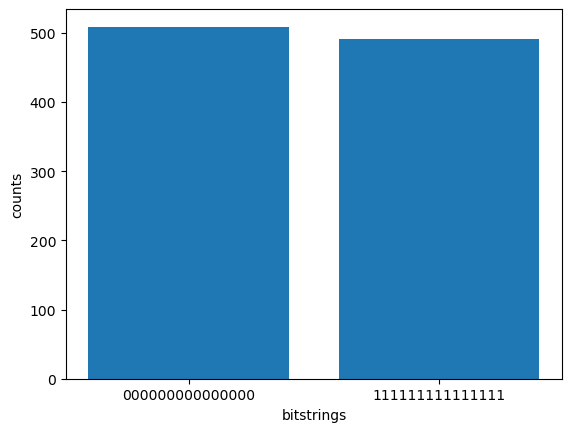

In [16]:
# plot using Counter
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstrings")
plt.ylabel("counts")

In [17]:
# define circuit
n_qubits = 3
ghz = ghz_circuit(n_qubits)

# add the state_vector ResultType
ghz.state_vector()
# add the Z \otimes Z \otimes Z expectation value
ghz.expectation(Z(0) @ Z(1) @ Z(2))
# add the amplitude for |111>
ghz.amplitude(state=["111"])
# print circuit including requested result types
print(ghz)

T  : │  0  │  1  │  2  │     Result Types     │
      ┌───┐             ┌────────────────────┐ 
q0 : ─┤ H ├───●─────────┤ Expectation(Z@Z@Z) ├─
      └───┘   │         └─────────┬──────────┘ 
            ┌─┴─┐       ┌─────────┴──────────┐ 
q1 : ───────┤ X ├───●───┤ Expectation(Z@Z@Z) ├─
            └───┘   │   └─────────┬──────────┘ 
                  ┌─┴─┐ ┌─────────┴──────────┐ 
q2 : ─────────────┤ X ├─┤ Expectation(Z@Z@Z) ├─
                  └───┘ └────────────────────┘ 
T  : │  0  │  1  │  2  │     Result Types     │

Additional result types: StateVector, Amplitude(111)


In [18]:
# run the circuit and output the results
task = device.run(ghz, shots=0)
result = task.result()

# print results
print("Final EXACT state vector:\n", result.values[0])
print("Expectation value <ZZZ>:", np.round(result.values[1], 5))
print("Amplitude <111|Final state>:", result.values[2])


Final EXACT state vector:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Expectation value <ZZZ>: 0.0
Amplitude <111|Final state>: {'111': np.complex128(0.7071067811865475+0j)}


In [31]:
local_simulator = BraketLocalBackend()
local_dm_simulator = BraketLocalBackend(name="braket_dm")

In [33]:
provider = BraketProvider()
#provider.backends(statuses=["ONLINE"], types=["SIMULATOR"])

